# Replica TMDPDF Bands

Replica-analysis notebook for plotting `x f_1(x,b;Q)` and `x f_1(x,k_T;Q)` with uncertainty bands from the stored replica refits.

This follows the same card-first Julia/TMD loading path as `TMDs/tmdpdf_plots.ipynb`, but evaluates the TMDPDF for the replica parameter ensemble and draws quantile bands on the 1D slices.


In [1]:
from julia.api import Julia
from julia import Main

import csv
import re
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams["figure.dpi"] = 120


## Configuration


In [ ]:
fit_name = "Final"
replica_results_path = Path("../Fits/replica_data/replica_0325.csv")

use_success_only = False
max_replicas = None # set to None to use all stored replicas
band_alpha = 15.865
central_curve_mode = "card"  # "card" or "replica_mean"

map_plot_flavor = "u"
map_x_values = [1e-3, 1e-2, 1e-1]
map_Q_values = [2.0, 4.75, 10.0]

b_plot_min = 1e-3
b_plot_max = 8.0
n_b_plot = 180

kt_plot_min = 0.0
kt_plot_max = 2.0
n_kt_plot = 120

FLAVORS = ["u", "ub", "d", "db", "s", "sb", "c", "cb", "b", "bb"]
FLAVOR_INDEX = {name: i for i, name in enumerate(FLAVORS)}
flavor_idx = FLAVOR_INDEX[map_plot_flavor]


## Load Card, Replicas, And Julia TMD Pieces


In [3]:
repo_root = Path("..").resolve()
TMD_root = (repo_root / "TMDs").resolve()
card_path = repo_root / "Cards" / f"{fit_name}.jl"
card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32", struct_match.group(1))
param_columns = [f"param_{i}" for i in range(len(param_names))]

init_matches = re.findall(r"(?ms)^\s*initial_params\s*=\s*\[([^\]]*)\]", card_text)
if not init_matches:
    raise ValueError(f"Could not find initial_params in {card_path}")
initial_params = np.asarray(
    [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?", init_matches[-1])],
    dtype=float,
)

def load_replica_results(path):
    expected_columns = ["replica_id", "pdf_replica_id", "success", "nfev", "best_chi2dN", *param_columns]
    with path.open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.reader(handle))
    if len(rows) < 2:
        raise ValueError(f"{path} does not contain any replica rows")
    body = []
    for row in rows[1:]:
        if not row or not any(part.strip() for part in row):
            continue
        if len(row) < len(expected_columns):
            raise ValueError(f"Replica row has {len(row)} columns; expected at least {len(expected_columns)}")
        body.append(row[: len(expected_columns)])
    df = pd.DataFrame(body, columns=expected_columns)
    for col in expected_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["replica_id", *param_columns]).copy()
    df["replica_id"] = df["replica_id"].astype(int)
    df["success"] = df["success"].astype("Int64")
    for col, name in zip(param_columns, param_names):
        df[name] = df[col]
    return df.sort_values("replica_id").reset_index(drop=True)

replica_results_df = load_replica_results(replica_results_path)
if use_success_only:
    replica_results_df = replica_results_df[replica_results_df["success"] == 1].reset_index(drop=True)
if max_replicas is not None:
    replica_results_df = replica_results_df.iloc[:max_replicas].copy()
if replica_results_df.empty:
    raise ValueError("No replica rows available after filtering")

def include(name):
    path = (repo_root / name).resolve()
    Main.eval(f'include(raw"{path}")')

include(f"Cards/{fit_name}.jl")

def Push_Params(params):
    lines = []
    for name, val in zip(param_names, params):
        lines.append(f"global NP_{name} = Float32({float(val)})")
    Main.eval("\n".join(lines))

Push_Params(initial_params)

active_table_name = str(Main.table_name)
np_cl_name = str(Main.NP_name)
np_julia_name = Path(np_cl_name).with_suffix(".jl").name
np_julia_path = TMD_root / "NP Parameterizations Julia" / np_julia_name
if not np_julia_path.exists():
    raise FileNotFoundError(f"No Julia NP file found for {np_cl_name}. Expected {np_julia_path.name}.")

Main.if_grid = True
try:
    Main.FastGK
except Exception:
    Main.eval("module FastGK end")
try:
    Main.eval("b0")
except Exception:
    Main.eval("const b0 = 1.1229189")

include("TMDs/Grids/initialization.jl")
include(f"TMDs/NP Parameterizations Julia/{np_julia_name}")
Push_Params(initial_params)
include("TMDs/TMDPDFs/TMDPDFN.jl")

display(pd.DataFrame({"param": param_names, "central_value": initial_params}))
print(f"fit_name = {fit_name}")
print(f"table_name = {active_table_name}")
print(f"replicas used = {len(replica_results_df)}")


,param,central_value
0,lambda1,0.023656
1,lambda2,1.054291
2,lambda3,-2.354365
3,logx0,-5.207703
4,sigx,1.103274
5,amp,-0.431106
6,BNP,1.494665
7,c0,0.070013
8,c1,0.027637


fit_name = BroadBump42LogGaussAlpha1NoLambda2
table_name = MSHT20N3LO-MC-4-2
replicas used = 100


## Evaluate Central Curves And Replica Bands


In [4]:
# Evaluate replica bands in k_T space only
def eval_component_kt(params, kt, x, Q, flavor_idx):
    Push_Params(params)
    values = np.asarray(Main.TMDPDF_kt_func(kt=float(kt), x=float(x), Q=float(Q)), dtype=float)
    return float(x * values[flavor_idx])

def evaluate_curve_bundle(params, kt_grid, x_values, Q_values):
    kt_curves = {}
    for Q in Q_values:
        for x in x_values:
            key = (Q, x)
            kt_curves[key] = np.array([eval_component_kt(params, kt, x, Q, flavor_idx) for kt in kt_grid])
    return kt_curves

kt_plot = np.linspace(kt_plot_min, kt_plot_max, n_kt_plot)
card_kt_curves = evaluate_curve_bundle(initial_params, kt_plot, map_x_values, map_Q_values)

replica_kt_samples = {(Q, x): [] for Q in map_Q_values for x in map_x_values}

for _, row in tqdm(replica_results_df.iterrows(), total=len(replica_results_df), desc='Evaluating replicas'):
    params = row[param_columns].to_numpy(dtype=float)
    kt_curves = evaluate_curve_bundle(params, kt_plot, map_x_values, map_Q_values)
    for key in replica_kt_samples:
        replica_kt_samples[key].append(kt_curves[key])

def compute_band(sample_list):
    if not sample_list:
        return None, None, None
    arr = np.stack(sample_list, axis=0)
    mean = np.mean(arr, axis=0)
    lo = np.percentile(arr, band_alpha, axis=0)
    hi = np.percentile(arr, 100.0 - band_alpha, axis=0)
    return mean, lo, hi

kt_stats = {key: compute_band(replica_kt_samples[key]) for key in replica_kt_samples}
replica_mean_kt_curves = {key: kt_stats[key][0] for key in kt_stats}
kt_bands = {key: (kt_stats[key][1], kt_stats[key][2]) for key in kt_stats}

if central_curve_mode == "card":
    central_kt_curves = card_kt_curves
elif central_curve_mode == "replica_mean":
    central_kt_curves = replica_mean_kt_curves
else:
    raise ValueError(f"Unknown central_curve_mode={central_curve_mode!r}; use 'card' or 'replica_mean'")


Evaluating replicas: 100%|██████████| 100/100 [02:26<00:00,  1.46s/it]


Central curve mode: card


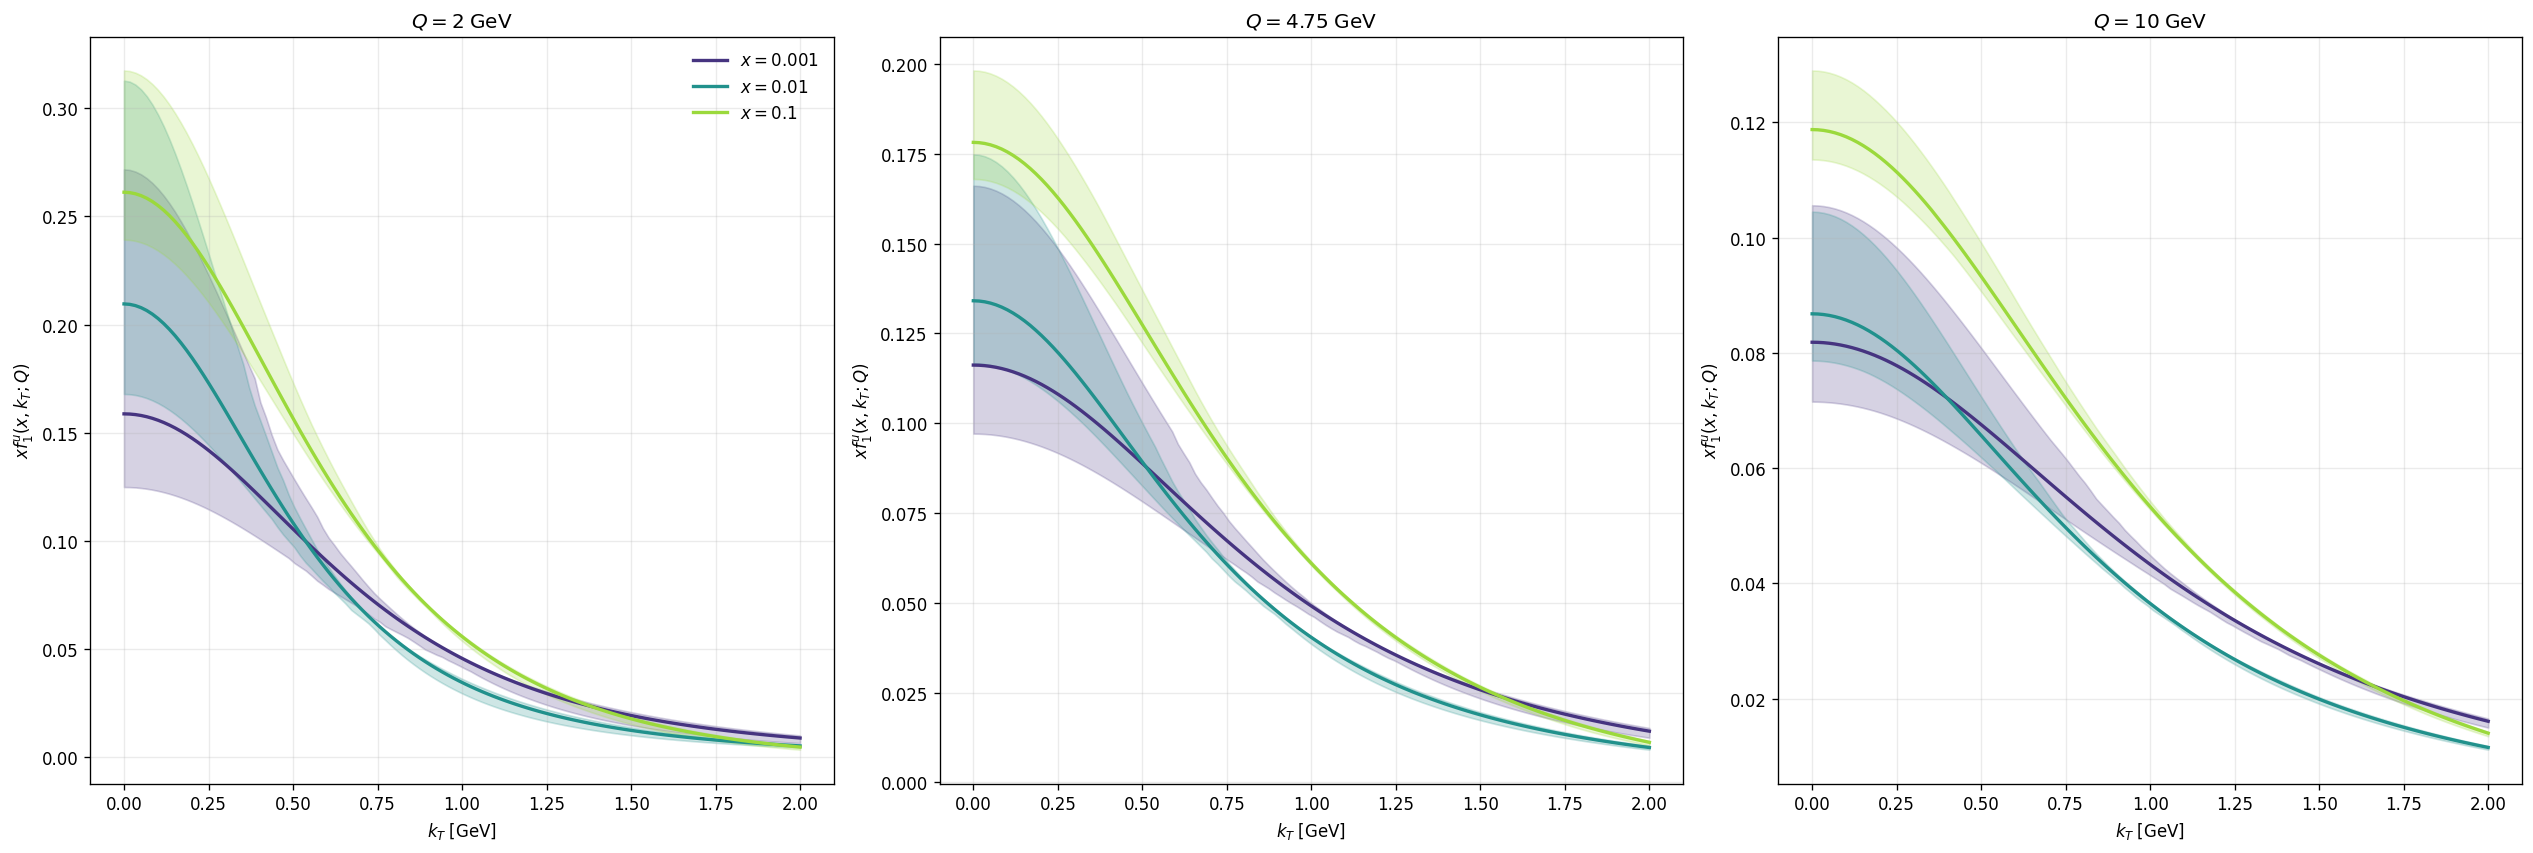

In [5]:
# Plot k_T-space TMDPDF bands with selectable central curve
fig, axes = plt.subplots(1, len(map_Q_values), figsize=(7 * len(map_Q_values), 7), constrained_layout=True)
if len(map_Q_values) == 1:
    axes = [axes]

colors = mpl.cm.viridis(np.linspace(0.15, 0.85, len(map_x_values)))

for ax, Q in zip(axes, map_Q_values):
    for color, x in zip(colors, map_x_values):
        key = (Q, x)
        lo, hi = kt_bands[key]
        central = central_kt_curves[key]
        if lo is not None:
            ax.fill_between(kt_plot, lo, hi, color=color, alpha=0.22)
        ax.plot(kt_plot, central, color=color, lw=2.0, label=fr'$x={x:g}$')

    ax.set_title(fr'$Q={Q:g}\;\mathrm{{GeV}}$')
    ax.set_xlabel(r'$k_T\;[\mathrm{GeV}]$')
    ax.set_ylabel(fr'$x f_1^{{{map_plot_flavor}}}(x,k_T;Q)$')
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, frameon=False, loc='best')
print(f"Central curve mode: {central_curve_mode}")
plt.show()


In [6]:
# Summary table at fixed k_T
kt_idx = int(np.argmin(np.abs(kt_plot - 1.0)))
summary_rows = []
for Q in map_Q_values:
    for x in map_x_values:
        key = (Q, x)
        kt_lo, kt_hi = kt_bands[key]
        summary_rows.append({
            'Q': Q,
            'x': x,
            'central_curve_mode': central_curve_mode,
            'central_xf(kT=1.0)': central_kt_curves[key][kt_idx],
            'band_lo_xf(kT=1.0)': None if kt_lo is None else kt_lo[kt_idx],
            'band_hi_xf(kT=1.0)': None if kt_hi is None else kt_hi[kt_idx],
        })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Q,x,central_curve_mode,central_xf(kT=1.0),band_lo_xf(kT=1.0),band_hi_xf(kT=1.0)
0,2.00,0.001,card,0.045099,0.041062,0.045066
1,2.00,0.010,card,0.033996,0.029002,0.035718
2,2.00,0.100,card,0.054842,0.052740,0.055529
3,4.75,0.001,card,0.048565,0.046040,0.049270
4,4.75,0.010,card,0.039826,0.037944,0.040081
5,4.75,0.100,card,0.060152,0.059539,0.060628
6,10.00,0.001,card,0.042925,0.041127,0.044421
7,10.00,0.010,card,0.036133,0.035336,0.036333
8,10.00,0.100,card,0.052736,0.052261,0.053675
